# GAAE Training — DELCODE Whole-Brain (Schaefer 400)

This notebook trains the GAAE model on whole-brain correlation matrices (400 nodes, Schaefer atlas)
from `DATA/DELCODE/__v3__/matrices`. It uses `GraphDatasetInMemoryFiltered` for whole-brain data.
It does a subject-level 60/20/20 train/val/test split via pre-generated CSVs.

In [1]:
import os
import sys
import json
from datetime import datetime
from pathlib import Path

import random
import numpy as np
import torch
from torch_geometric.loader import DataLoader

base_dir = Path('/mnt/e/fyassine/ad-early-detection/MODEL')
sys.path.insert(0, str(base_dir))

from model.GAAE.models import GraphAttentionAutoencoderConditioned
from model.GAAE.dataset import GraphDatasetInMemoryFiltered
from model.GAAE.utils import knn_binary_adjacency_matrix_no_diag
from model.GAAE.train import train_model_with_val_notebook_train_loss

## Configuration

In [2]:
WANDB_PROJECT = "ad-early-detection-whole-brain"

try:
    import wandb
    wandb.login()
except Exception:
    wandb = None
    print("wandb not available — logging disabled")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wunderlich/.netrc.
wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
hyperparams_path = base_dir / "configs" / "gaae_delcode_whole_brain.json"
if not hyperparams_path.exists():
    print(f"Config not found at {hyperparams_path}. Using defaults.")
    hyperparams = {
        "seed": 42,
        "batch_size": 8,
        "learning_rate": 0.001,
        "adj_loss_weight": 1.0,
        "epochs": 100,
        "early_stopping_patience": 15,
        "latent_dim": 64,
        "num_heads": 2,
        "cond_dim": 2,
        "dropout": 0.3,
        "adjacency_k": 8,
        "num_workers": 4,
    }
else:
    with open(hyperparams_path, "r") as handle:
        hyperparams = json.load(handle)

seed = hyperparams["seed"]
batch_size = hyperparams["batch_size"]
learning_rate = hyperparams["learning_rate"]
adj_loss_weight = hyperparams["adj_loss_weight"]
n_epochs = hyperparams["epochs"]
early_stopping_patience = hyperparams["early_stopping_patience"]

out_features = hyperparams["latent_dim"]
num_heads = hyperparams["num_heads"]
cond_dim = hyperparams["cond_dim"]
dropout = hyperparams["dropout"]

adjacency_args = {"k": hyperparams["adjacency_k"]}
num_workers = hyperparams["num_workers"]
file_variant = hyperparams.get("file_variant", "z_transformed")

print(f"Hyperparameters: {json.dumps(hyperparams, indent=2)}")

Config not found at /mnt/e/fyassine/ad-early-detection/MODEL/configs/gaae_delcode_whole_brain.json. Using defaults.
Hyperparameters: {
  "seed": 42,
  "batch_size": 8,
  "learning_rate": 0.001,
  "adj_loss_weight": 1.0,
  "epochs": 100,
  "early_stopping_patience": 15,
  "latent_dim": 64,
  "num_heads": 2,
  "cond_dim": 2,
  "dropout": 0.3,
  "adjacency_k": 8,
  "num_workers": 4
}


In [5]:
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

def worker_init_fn(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print(f"Random seed set to: {seed}")

Random seed set to: 42


## Dataset

In [6]:
wb_data_root = "/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices"

metadata_dir = "/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/metadata"
gaae_splits_dir = os.path.join(metadata_dir, "splits_gaae") if os.path.exists(os.path.join(metadata_dir, "splits_gaae")) else os.path.join("/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata", "splits_gaae")
train_csv = os.path.join(gaae_splits_dir, "train.csv")
val_csv   = os.path.join(gaae_splits_dir, "val.csv")
test_csv  = os.path.join(gaae_splits_dir, "test.csv")

train_dataset = GraphDatasetInMemoryFiltered(
    root=wb_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=train_csv,
    separator=",",
    file_variant=file_variant,
)

val_dataset = GraphDatasetInMemoryFiltered(
    root=wb_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=val_csv,
    separator=",",
    file_variant=file_variant,
)

test_dataset = GraphDatasetInMemoryFiltered(
    root=wb_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=test_csv,
    separator=",",
    file_variant=file_variant,
)

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Feature shape: {train_dataset[0].x.shape}")

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if num_workers > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if num_workers > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

dataset_info = {
    "dataset_name": "Whole-brain Schaefer 400-node (60/20/20 subject-level split)",
    "kNN_param": adjacency_args['k'],
    "correlation_type": file_variant,
    "num_features": train_dataset[0].x.size(1),
    "train_dataset_size": len(train_dataset),
    "val_dataset_size": len(val_dataset),
    "test_dataset_size": len(test_dataset),
    "batch_size": batch_size
}
print(f"Dataset info: {json.dumps(dataset_info, indent=2)}")

Train: 447 samples
Val:   92 samples
Test:  59 samples
Feature shape: torch.Size([200, 200])
Dataset info: {
  "dataset_name": "Whole-brain Schaefer 400-node (60/20/20 subject-level split)",
  "kNN_param": 8,
  "correlation_type": "z_transformed",
  "num_features": 200,
  "train_dataset_size": 447,
  "val_dataset_size": 92,
  "test_dataset_size": 59,
  "batch_size": 8
}


## Model

In [7]:
in_features = train_dataset[0].x.size(1)
hidden_dim = in_features

In [8]:
model = GraphAttentionAutoencoderConditioned(
    in_features=in_features,
    hidden_dim=hidden_dim,
    out_features=out_features,
    cond_dim=cond_dim,
    num_heads=num_heads,
    dropout=dropout
).to(device)

model_config = {
    "model_type": model.__class__.__name__,
    "in_features": in_features,
    "hidden_size": hidden_dim,
    "latent_dim": out_features,
    "attention_heads": num_heads,
    "device": device.type,
    "dropout": dropout
}

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"Model: {model.__class__.__name__}")
print(f"  in_features={in_features}, hidden_dim={hidden_dim}, out_features={out_features}")
print(f"  num_heads={num_heads}, dropout={dropout}")

Model: GraphAttentionAutoencoderConditioned
  in_features=200, hidden_dim=200, out_features=64
  num_heads=2, dropout=0.3


In [9]:
USE_CHECKPOINT = False

CHECKPOINT_SEARCH_DIRS = [
    str(base_dir / "notebooks" / "checkpoints_gaae_whole_brain"),
]

if USE_CHECKPOINT:
    checkpoint_candidates = sorted(
        [
            (run_dir.name, str(model_file), str(run_dir))
            for checkpoint_dir in CHECKPOINT_SEARCH_DIRS
            for base_dir_path in [Path(checkpoint_dir)]
            if base_dir_path.is_dir()
            for run_dir in sorted(base_dir_path.iterdir())
            if run_dir.is_dir()
            for model_file in [run_dir / f"model_{run_dir.name}.pth"]
            if model_file.exists()
        ],
        key=lambda x: x[0],
    )

    if not checkpoint_candidates:
        raise FileNotFoundError(
            "No GAAE checkpoints found. Train first or set USE_CHECKPOINT=False."
        )

    print("Available GAAE checkpoints:")
    for i, (run_name, _, run_dir) in enumerate(checkpoint_candidates):
        print(f"  {i}: {run_name} ({run_dir})")

    selected_run_index = int(input("Select a checkpoint by index: "))
    SELECTED_RUN_NAME, GAAE_CHECKPOINT_PATH, SELECTED_RUN_DIR = checkpoint_candidates[selected_run_index]

    checkpoint_obj = torch.load(GAAE_CHECKPOINT_PATH, map_location=device)
    if isinstance(checkpoint_obj, torch.nn.Module):
        model = checkpoint_obj.to(device)
    elif isinstance(checkpoint_obj, dict):
        model.load_state_dict(checkpoint_obj)
        model = model.to(device)
    else:
        raise TypeError("Unsupported checkpoint format. Expected torch.nn.Module or state_dict.")

    best_model = model
    history = {"train_loss": [], "val_loss": []}
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_name = f"checkpoint_{SELECTED_RUN_NAME}_{run_timestamp}"
    print(f"Loaded checkpoint from {GAAE_CHECKPOINT_PATH}")
    print("Training skipped because USE_CHECKPOINT=True")
else:
    best_model, history = train_model_with_val_notebook_train_loss(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        batch_size=batch_size,
        learning_rate=learning_rate,
        model_config=model_config,
        adj_loss_weight=adj_loss_weight,
        epochs=n_epochs,
        early_stopping_patience=early_stopping_patience,
        dataset_info=dataset_info,
        project_name=WANDB_PROJECT
    )

    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    try:
        wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else "run"
    except Exception:
        wandb_run_name = "run"
    wandb_run_name = str(wandb_run_name).replace(" ", "-")
    run_name = f"{wandb_run_name}_{run_timestamp}"

    checkpoint_root = base_dir / "notebooks" / "checkpoints_gaae_whole_brain"
    os.makedirs(checkpoint_root, exist_ok=True)
    run_artifact_dir = checkpoint_root / run_name
    os.makedirs(run_artifact_dir, exist_ok=True)

    model_file = run_artifact_dir / f"model_{run_name}.pth"
    torch.save(best_model, str(model_file))
    print(f"Saved best model to {model_file}")

    config_to_save = {
        "run_name": run_name,
        "wandb_run_name": wandb_run_name,
        "timestamp": run_timestamp,
        "dataset_info": dataset_info,
        "model_config": model_config,
        "training_config": {
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "adj_loss_weight": adj_loss_weight,
            "epochs": n_epochs,
            "early_stopping_patience": early_stopping_patience
        }
    }

    def json_serial(obj):
        if isinstance(obj, (datetime, torch.device)):
            return str(obj)
        raise TypeError(f"Type {type(obj)} not serializable")

    config_file = run_artifact_dir / "run_config.json"
    with open(config_file, "w") as f:
        json.dump(config_to_save, f, indent=4, default=json_serial)
    print(f"Saved run configuration to {config_file}")

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Saved best model to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth
Saved run configuration to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/run_config.json


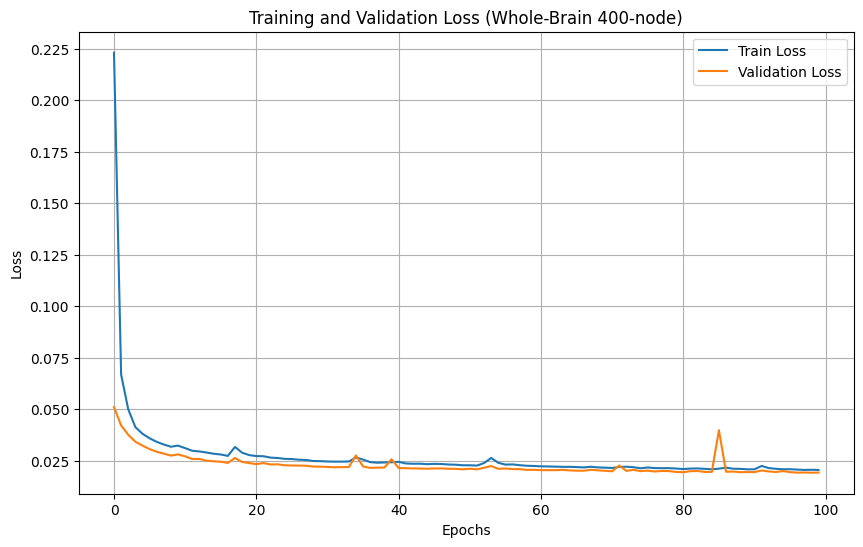

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Whole-Brain 400-node)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# state = torch.load(str("../Fabian's models/200_Delcode_healthy_age_sex_conditioned/best_model_4000_epochs.pth"), map_location=device)
# model.load_state_dict(state)
# model.to(device)

## Loss

/tmp/ipykernel_240859/902099978.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


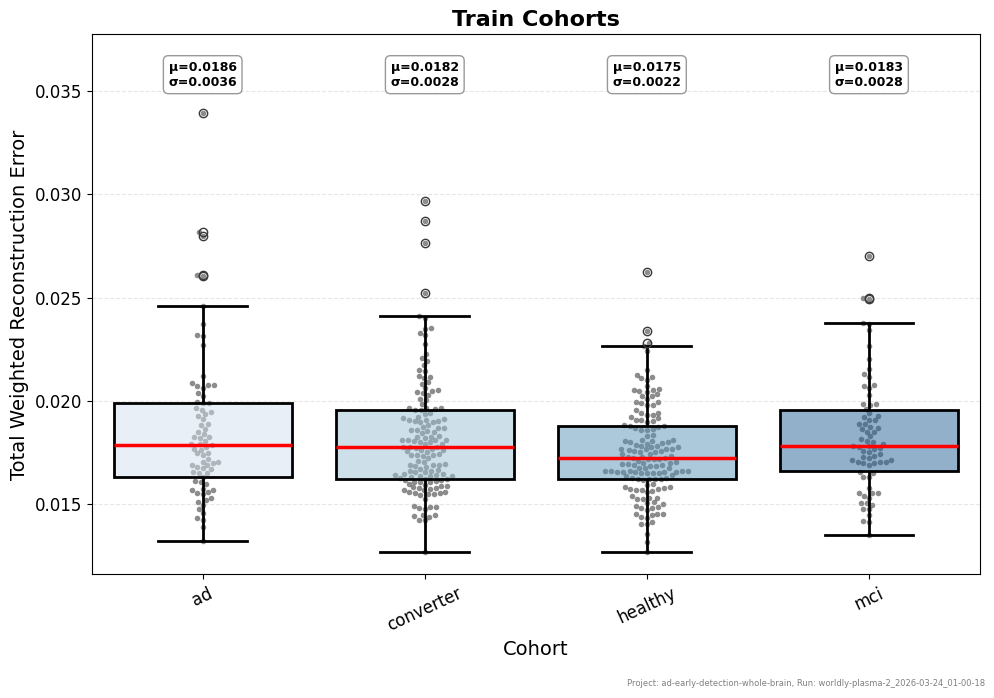

/tmp/ipykernel_240859/902099978.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


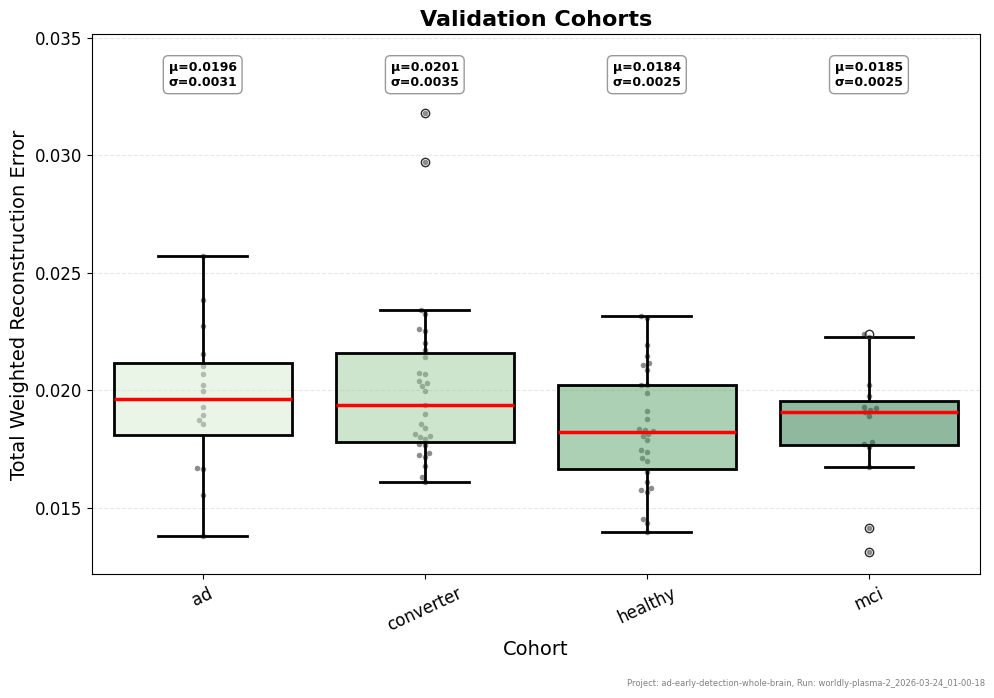

Train cohort counts:
Cohort
ad            77
converter    146
healthy      150
mci           74
dtype: int64

Validation cohort counts:
Cohort
ad           16
converter    31
healthy      30
mci          15
dtype: int64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj

from model.GAAE.utils import calculate_dense_adjacency

train_split_df = pd.read_csv(train_csv)
val_split_df = pd.read_csv(val_csv)

assert "Repseudonym" in train_split_df.columns and "diagnosis" in train_split_df.columns
assert "Repseudonym" in val_split_df.columns and "diagnosis" in val_split_df.columns

allowed_cohorts = {"ad", "converter", "healthy", "mci"}

combined_split_df = pd.concat([train_split_df, val_split_df], ignore_index=True)
subject_cohort_map = (
    combined_split_df[["Repseudonym", "diagnosis"]]
    .drop_duplicates(subset=["Repseudonym"], keep="first")
    .assign(
        Repseudonym=lambda d: d["Repseudonym"].astype(str).str.strip(),
        diagnosis=lambda d: d["diagnosis"].astype(str).str.lower().str.strip(),
    )
    .set_index("Repseudonym")["diagnosis"]
    .to_dict()
)

def compute_split_errors_by_cohort(dataset, split_name):
    records = []
    unknown_ids = []
    model.eval()

    for data in dataset:
        data = data.to(device)
        x, edge_index, edge_attr = data.x, data.edge_index, getattr(data, "edge_attr", None)
        patient_id = str(getattr(data, "patient_id", "")).strip()
        cohort = subject_cohort_map.get(patient_id)

        if cohort not in allowed_cohorts:
            unknown_ids.append(patient_id)
            continue

        cond_vec = torch.tensor(
            [[data.patient_age.item(), float(data.patient_sex.item())]],
            device=device,
        )
        batch_mask = torch.zeros(x.size(0), dtype=torch.long, device=device)

        with torch.no_grad():
            _, x_reconstructed, adj_reconstructed, _ = model(
                x, edge_index, edge_attr, cond_vec, batch_mask
            )

        x_error = F.mse_loss(x_reconstructed, x).item()
        adj_original = calculate_dense_adjacency(data).to(device)
        adj_reconstructed_dense = to_dense_adj(
            edge_index, edge_attr=adj_reconstructed, max_num_nodes=x.size(0)
        ).squeeze(0)
        adj_error = F.binary_cross_entropy(adj_reconstructed_dense, adj_original).item()
        total_error = x_error + adj_loss_weight * adj_error

        records.append(
            {
                "Split": split_name,
                "Cohort": cohort,
                "Total Error": total_error,
            }
        )

    if unknown_ids:
        unique_unknown = sorted(set(unknown_ids))
        raise ValueError(
            f"{split_name}: found {len(unique_unknown)} IDs without allowed diagnosis mapping. "
            f"Examples: {unique_unknown[:10]}"
        )

    return pd.DataFrame(records)

train_errors_df = compute_split_errors_by_cohort(train_dataset, "Train")
val_errors_df = compute_split_errors_by_cohort(val_dataset, "Validation")

cohort_order = [
    c for c in ["ad", "converter", "healthy", "mci"]
    if c in set(train_errors_df["Cohort"]) | set(val_errors_df["Cohort"])
]

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

split_frames = [
    ("Train", train_errors_df, "Blues"),
    ("Validation", val_errors_df, "Greens"),
]

for split_name, split_df, palette_name in split_frames:
    plt.figure(figsize=(10, 7))
    ax = plt.gca()

    sns.swarmplot(
        data=split_df,
        x="Cohort",
        y="Total Error",
        order=cohort_order,
        color=".25",
        size=4,
        alpha=0.6,
        zorder=1,
        ax=ax,
    )

    boxplot = sns.boxplot(
        data=split_df,
        x="Cohort",
        y="Total Error",
        order=cohort_order,
        palette=palette_name,
        showcaps=True,
        boxprops={"edgecolor": "black", "linewidth": 2},
        medianprops={"color": "red", "linewidth": 2.5},
        whiskerprops={"color": "black", "linewidth": 2},
        capprops={"color": "black", "linewidth": 2},
        zorder=2,
        ax=ax,
    )

    alpha_value = 0.5
    for patch in boxplot.patches:
        facecolor = patch.get_facecolor()
        if len(facecolor) == 4:
            r, g, b, _ = facecolor
        else:
            r, g, b = facecolor[:3]
        patch.set_facecolor((r, g, b, alpha_value))

    y_top = split_df["Total Error"].max()
    y_min = split_df["Total Error"].min()
    y_span = y_top - y_min if y_top > y_min else 1.0
    ax.set_ylim(y_min - 0.05 * y_span, y_top + 0.18 * y_span)

    for i, cohort in enumerate(cohort_order):
        cohort_data = split_df[split_df["Cohort"] == cohort]["Total Error"]
        if cohort_data.empty:
            continue
        mean_val = cohort_data.mean()
        std_val = cohort_data.std(ddof=1) if len(cohort_data) > 1 else 0.0
        ax.text(
            i,
            y_top + 0.12 * y_span,
            f"μ={mean_val:.4f}\nσ={std_val:.4f}",
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8),
        )

    ax.set_title(f"{split_name} Cohorts", fontsize=16, fontweight="bold")
    ax.set_xlabel("Cohort", fontsize=14)
    ax.set_ylabel("Total Weighted Reconstruction Error", fontsize=14)
    ax.tick_params(axis="x", rotation=25, labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    if globals().get("USE_CHECKPOINT", False) and "SELECTED_RUN_NAME" in globals():
        display_run_name = SELECTED_RUN_NAME
    else:
        display_run_name = globals().get("run_name", "run")

    plt.figtext(
        0.99,
        0.01,
        f"Project: {WANDB_PROJECT}, Run: {display_run_name}",
        horizontalalignment="right",
        verticalalignment="bottom",
        fontsize=6,
        alpha=0.5,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

print("Train cohort counts:")
print(train_errors_df.groupby("Cohort").size().sort_index())

print("\nValidation cohort counts:")
print(val_errors_df.groupby("Cohort").size().sort_index())

In [14]:
# reconstruction_errors = {
#     'Train': {
#         'x_errors': train_x_errors,
#         'adj_errors': train_adj_errors,
#         'total_errors': train_total_weighted_errors,
#         'patient_ids': train_ids
#     },
#     'Val': {
#         'x_errors': val_x_errors,
#         'adj_errors': val_adj_errors,
#         'total_errors': val_total_weighted_errors,
#         'patient_ids': val_ids
#     }
# }

# for key in reconstruction_errors.keys():
#     x_errors = reconstruction_errors[key]['x_errors']
#     adj_errors = reconstruction_errors[key]['adj_errors']
#     total_errors = reconstruction_errors[key]['total_errors']
#     patient_ids = reconstruction_errors[key]['patient_ids']

#     total_errors = np.array(total_errors)
#     if total_errors.size == 0:
#         reconstruction_errors[key]['x_errors'] = []
#         reconstruction_errors[key]['adj_errors'] = []
#         reconstruction_errors[key]['total_errors'] = []
#         reconstruction_errors[key]['patient_ids'] = []
#         continue

#     valid_mask = ~np.isnan(total_errors)

#     reconstruction_errors[key]['x_errors'] = np.array(x_errors)[valid_mask].tolist()
#     reconstruction_errors[key]['adj_errors'] = np.array(adj_errors)[valid_mask].tolist()
#     reconstruction_errors[key]['total_errors'] = total_errors[valid_mask].tolist()
#     reconstruction_errors[key]['patient_ids'] = np.array(patient_ids)[valid_mask].tolist()

### Train vs. Validation

In [15]:
# from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, precision_recall_curve

# train_errors = reconstruction_errors['Train']['total_errors']
# val_errors = reconstruction_errors['Val']['total_errors']

# all_errors = train_errors + val_errors

# print(f"Total samples: {len(all_errors)}")
# print(f"  Train: {len(train_errors)}")
# print(f"  Val: {len(val_errors)}")

In [16]:
# data = []
# for dataset_name, errors in reconstruction_errors.items():
#     total_errors = errors['total_errors']
#     for error in total_errors:
#         data.append({'Dataset': dataset_name, 'Total Error': error})

# df = pd.DataFrame(data)
# df = df.dropna(subset=['Total Error'])

# label_map = {
#     'Train': 'Train (All Cohorts)',
#     'Val': 'Val (All Cohorts)'
# }
# df['Cohort'] = df['Dataset'].map(label_map)
# df = df.dropna(subset=['Cohort'])
# cohort_order = [
#     'Train (All Cohorts)',
#     'Val (All Cohorts)'
# ]

# print(f"Dataset sizes:")
# for cohort in cohort_order:
#     count = len(df[df['Cohort'] == cohort])
#     print(f"  {cohort}: {count}")

In [17]:
# plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['ps.fonttype'] = 42

# plt.figure(figsize=(10, 7))
# sns.swarmplot(
#     x='Cohort', y='Total Error', data=df,
#     order=cohort_order,
#     color=".25", size=4, alpha=0.6, zorder=1
# )

# boxplot = sns.boxplot(
#     x='Cohort', y='Total Error', data=df,
#     order=cohort_order,
#     palette='Blues',
#     showcaps=True,
#     boxprops={'edgecolor': 'black', 'linewidth': 2},
#     medianprops={'color': 'red', 'linewidth': 2.5},
#     whiskerprops={'color': 'black', 'linewidth': 2},
#     capprops={'color': 'black', 'linewidth': 2},
#     zorder=2
# )

# alpha_value = 0.5
# for patch in boxplot.patches:
#     facecolor = patch.get_facecolor()
#     if len(facecolor) == 4:
#         r, g, b, a = facecolor
#     else:
#         r, g, b = facecolor[:3]
#         a = 1.0
#     patch.set_facecolor((r, g, b, alpha_value))

# for i, cohort in enumerate(cohort_order):
#     cohort_data = df[df['Cohort'] == cohort]['Total Error']
#     mean_val = cohort_data.mean()
#     median_val = cohort_data.median()
#     plt.text(i, plt.ylim()[1] * 0.98, f'μ={mean_val:.4f}\nM={median_val:.4f}', 
#              ha='center', va='top', fontsize=9, fontweight='bold',
#              bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8))

# plt.title('Reconstruction Errors\nTrained on: AD + MCI Stable + Healthy + Converter (85/15)', fontsize=16, fontweight='bold')
# plt.xlabel('Cohort', fontsize=14)
# plt.ylabel('Total Weighted Reconstruction Error', fontsize=14)
# plt.xticks(rotation=0, fontsize=12)
# plt.yticks(fontsize=12)
# plt.grid(axis='y', alpha=0.3, linestyle='--')

# plt.figtext(0.99, 0.01, f"Project: {WANDB_PROJECT}, Run: {wandb_run_name}", horizontalalignment='right', verticalalignment='bottom', fontsize=6, alpha=0.5)
# plt.tight_layout()
# plt.show()

### Healthy vs. AD vs. Converters vs. sMCI Boxplots

In [18]:
# val_indices_in_subset = val_dataset.indices
# val_indices_in_original = [training_indices[i] for i in val_indices_in_subset]

# val_cohorts = {
#     'AD': [],
#     'MCI Stable': [],
#     'Healthy': [],
#     'Converter': []
# }

# for subset_idx, original_idx in zip(val_indices_in_subset, val_indices_in_original):
#     for cohort_name, (start, end) in cohort_offsets.items():
#         if start <= original_idx < end:
#             val_cohorts[cohort_name].append(subset_idx)
#             break

# print(f"Validation cohort sizes:")
# for cohort, indices in val_cohorts.items():
#     print(f"  {cohort}: {len(indices)}")

In [19]:
# from torch.utils.data import Subset

# val_cohort_errors = {}

# for cohort_name, cohort_indices in val_cohorts.items():
#     cohort_subset = Subset(combined_dataset, cohort_indices)
    
#     x_errors, adj_errors, total_errors, patient_ids = \
#         evaluate_reconstruction_errors_with_ids(cohort_subset, model, device, adj_loss_weight=ADJ_LOSS_WEIGHT)
    
#     total_errors = np.array(total_errors)
#     valid_mask = ~np.isnan(total_errors)
    
#     val_cohort_errors[cohort_name] = {
#         'x_errors': np.array(x_errors)[valid_mask].tolist(),
#         'adj_errors': np.array(adj_errors)[valid_mask].tolist(),
#         'total_errors': total_errors[valid_mask].tolist(),
#         'patient_ids': np.array(patient_ids)[valid_mask].tolist()
#     }
    
#     print(f"{cohort_name}: {len(total_errors[valid_mask])} valid samples")

In [20]:
# val_data = []
# for cohort_name, errors in val_cohort_errors.items():
#     total_errors = errors['total_errors']
#     for error in total_errors:
#         val_data.append({'Cohort': cohort_name, 'Total Error': error})

# val_df = pd.DataFrame(val_data)
# val_df = val_df.dropna(subset=['Total Error'])

# val_cohort_order = ['Healthy', 'MCI Stable', 'Converter', 'AD']

# print(f"Validation cohort sizes:")
# for cohort in val_cohort_order:
#     count = len(val_df[val_df['Cohort'] == cohort])
#     print(f"  {cohort}: {count}")

In [21]:
# plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['ps.fonttype'] = 42

# plt.figure(figsize=(14, 7))
# sns.swarmplot(
#     x='Cohort', y='Total Error', data=val_df,
#     order=val_cohort_order,
#     color=".25", size=4, alpha=0.6, zorder=1
# )

# boxplot = sns.boxplot(
#     x='Cohort', y='Total Error', data=val_df,
#     order=val_cohort_order,
#     palette='Blues',
#     showcaps=True,
#     boxprops={'edgecolor': 'black', 'linewidth': 2},
#     medianprops={'color': 'red', 'linewidth': 2.5},
#     whiskerprops={'color': 'black', 'linewidth': 2},
#     capprops={'color': 'black', 'linewidth': 2},
#     zorder=2
# )

# alpha_value = 0.5
# for patch in boxplot.patches:
#     r, g, b, _ = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, alpha_value))

# for i, cohort in enumerate(val_cohort_order):
#     cohort_data = val_df[val_df['Cohort'] == cohort]['Total Error']
#     mean_val = cohort_data.mean()
#     median_val = cohort_data.median()
#     plt.text(i, plt.ylim()[1] * 0.98, f'μ={mean_val:.4f}\nM={median_val:.4f}', 
#              ha='center', va='top', fontsize=9, fontweight='bold',
#              bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8))

# plt.title('Validation Reconstruction Errors by Cohort\nTrained on: AD + MCI Stable + Healthy + Converter (85/15)', fontsize=16, fontweight='bold')
# plt.xlabel('Cohort', fontsize=14)
# plt.ylabel('Total Weighted Reconstruction Error', fontsize=14)
# plt.xticks(rotation=25, fontsize=12)
# plt.yticks(fontsize=12)
# plt.grid(axis='y', alpha=0.3, linestyle='--')

# plt.figtext(0.99, 0.01, f"Project: {WANDB_PROJECT}, Run: {wandb_run_name}", horizontalalignment='right', verticalalignment='bottom', fontsize=6, alpha=0.5)
# plt.tight_layout()
# plt.show()

In [22]:
# summary_table = df.groupby('Cohort')['Total Error'].agg(['count', 'mean', 'std', 'min', 'max']).reindex(cohort_order)

# if 'run_artifact_dir' not in globals():
#     run_artifact_dir = os.path.join("checkpoints", wandb_run_name)
#     os.makedirs(run_artifact_dir, exist_ok=True)

# loss_artifact = {
#     'timestamp': datetime.now().strftime("%Y-%m-%d_%H-%M-%S"),
#     'run_name': wandb_run_name,
#     'model_path': model_file if 'model_file' in globals() else None,
#     'dataset_info': dataset_info,
#     'reconstruction_errors': reconstruction_errors,
#     'cohort_dataframe': df.to_dict(orient="list"),
#     'summary_table': summary_table.reset_index().to_dict(orient="list"),
#     'cohort_order': cohort_order,
#     'label_map': label_map
# }

# loss_filename = f"losses_{wandb_run_name}.pkl"
# loss_file = os.path.join(run_artifact_dir, loss_filename)
# with open(loss_file, "wb") as fp:
#     pickle.dump(loss_artifact, fp)

# print(f"Saved loss artifacts to {loss_file}")

In [23]:
try:
    wandb.finish()
except Exception:
    pass

Train Loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Val Loss,▇▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁█▁▁▁▁
Train Loss,0.02043
Val Loss,0.01916
